# Demo 3 — Seleksi Fitur pada Data Gambar

## Tujuan
Mahasiswa memahami:
* gambar terdiri dari pixel,
* tidak semua bagian (pixel) dari gambar itu penting,
* fitur visual (pixel) dapat direduksi/dipilih.

## Tahap 1 — Tampilkan Gambar Asli
Kita menggunakan dataset MNIST (Digit Tulisan Tangan). Dataset ini ringan dan sangat cocok untuk demo visual.

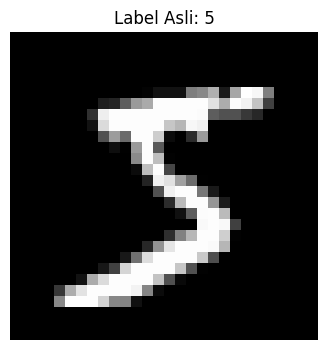

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Mengunduh sebagian data agar ringan dan cepat
mnist = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)
X = mnist.data[:1000]
y = mnist.target[:1000]

sample_image = X[0].reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Label Asli: {y[0]}")
plt.axis('off')
plt.show()

## Tahap 2 — Tampilkan Representasi Pixel
Komputer tidak melihat "angka 5", komputer melihat kumpulan angka pixel (0-255).

In [2]:
print("Bentuk asli 1 gambar (flatten):", X[0].shape)
print("Setiap gambar diubah menjadi", X[0].shape[0], "fitur pixel.")
print("\nSebagian nilai pixel di bagian tengah gambar:")
print(X[0][400:450])

# Insight: "Gambar direpresentasikan sebagai kumpulan angka/fitur 1 dimensi yang panjang."

Bentuk asli 1 gambar (flatten): (784,)
Setiap gambar diubah menjadi 784 fitur pixel.

Sebagian nilai pixel di bagian tengah gambar:
[  0   0   0   0   0  81 240 253 253 119  25   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 186
 253 253 150  27   0   0   0   0   0   0   0   0   0   0]


## Tahap 3 — Seleksi Fitur Pixel
Pixel di bagian pinggir gambar rata-rata berwarna hitam (0) pada semua data. Pixel ini tidak memiliki informasi (variansi rendah). Kita bisa membuangnya!

In [3]:
from sklearn.feature_selection import VarianceThreshold

# Buang pixel yang variansinya rendah (hampir tidak pernah berubah warnanya antar gambar)
selector = VarianceThreshold(threshold=0.1)
X_selected = selector.fit_transform(X)

print(f"Jumlah pixel asli: {X.shape[1]}")
print(f"Jumlah pixel terpilih: {X_selected.shape[1]}")
print(f"Kita berhasil membuang {(X.shape[1] - X_selected.shape[1])} pixel yang tidak berguna!")

Jumlah pixel asli: 784
Jumlah pixel terpilih: 608
Kita berhasil membuang 176 pixel yang tidak berguna!


## Tahap 4 — Visualisasi Pixel Terpilih
Mari kita lihat bagian mana dari gambar yang sebenarnya dianggap "penting" oleh seleksi fitur.

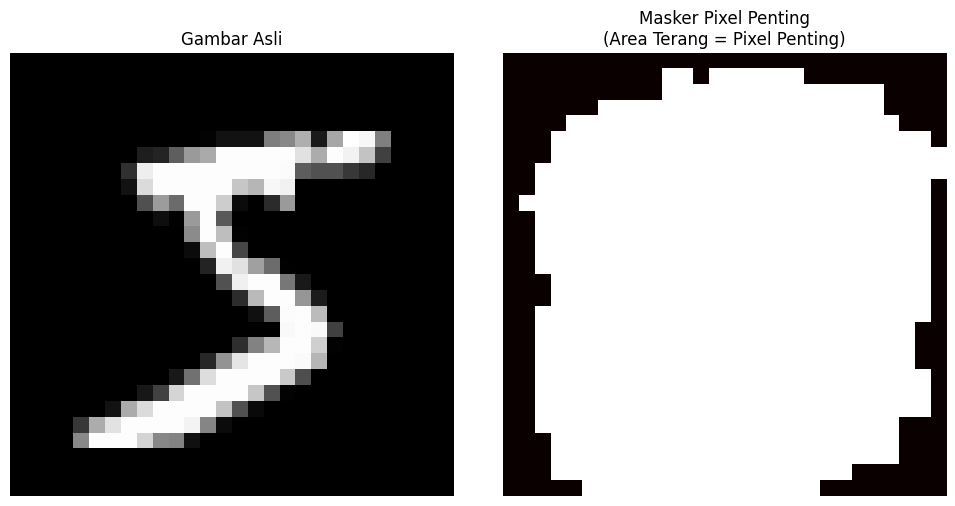

In [4]:
# Masker fitur terpilih
mask = selector.get_support()
mask_2d = mask.reshape(28, 28)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap='gray')
plt.title("Gambar Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_2d, cmap='hot')
plt.title("Masker Pixel Penting\n(Area Terang = Pixel Penting)")
plt.axis('off')

plt.tight_layout()
plt.show()

## Tahap 5 — Insight Penutup
* Bagian pinggir gambar biasanya hanya background kosong (noise/redundant).
* Bagian tengah gambar yang membentuk pola digit adalah informasi yang berguna.
* Seleksi fitur dapat mengurangi kompleksitas ukuran model tanpa kehilangan informasi berharga.

**Kesimpulan:** Seleksi fitur pada data gambar berarti **memilih pola visual/pixel penting**.